# 기술통계

기술통계<font size='2'>descriptive statistics</font>는 수집된 데이터의 특성을 요약하고 설명하는 통계 기법이다. 데이터를 대표하는 값(평균값, 중앙값, 최빈값)과 데이터의 퍼짐 정도를 나타내는 값(분산, 표준편차, 범위, 사분범위) 등을 통해 데이터의 전반적인 특성을 파악한다.

기술통계는 크게 두 가지 범주로 나뉜다.

- 중심 경향성: 데이터 전체를 하나의 대표값으로 요약한다.
  - 평균값<font size='2'>mean</font>: 모든 값의 합을 데이터 개수로 나눈 값. 극단적인 값(이상치)에 민감하다.
  - 중앙값<font size='2'>median</font>: 데이터를 크기 순으로 정렬했을 때 가운데 위치하는 값. 이상치의 영향을 별로 받지 않는다.
  - 최빈값<font size='2'>mode</font>: 데이터에서 가장 빈번하게 등장하는 값. 범주형 데이터에도 적용 가능하다.

- 산포도: 데이터가 중심 값 주위에 얼마나 퍼져 있는지를 나타낸다.
  - 범위<font size='2'>range</font>: 최댓값과 최솟값의 차이. 계산이 간단하지만 이상치에 취약하다.
  - 분산<font size='2'>variance</font>: 각 값과 평균의 차이(편차)를 제곱하여 평균한 값.
  - 표준편차<font size='2'>standard deviation</font>: 분산의 제곱근. 데이터와 동일한 단위를 가지며 가장 널리 쓰이는 산포 측도이다.
  - 사분범위<font size='2'>interquartile range, IQR</font>: 제3사분위수(Q3)에서 제1사분위수(Q1)를 뺀 값. 중간 50% 데이터의 퍼짐 정도를 나타내며 이상치에 강건하다.

기술통계는 데이터 분석의 첫 단계로서, 탐색적 데이터 분석<font size='2'>EDA</font>의 핵심 요소다.

**기본 설정**

탐색적 데이터분석(EDA)에 필요한 핵심 라이브러리를 불러온다.

- `numpy`: 수치 연산
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화
- `seaborn`: 통계 기반 데이터 시각화

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [2]:
pd.set_option('display.precision', 6)

**데이터 저장소**

In [3]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

## 데이터셋 불러오기

`body_df.csv` 파일은 성인 남녀 1,000명(여성 500명, 남성 500명)의 신체 정보를 담고 있으며, 6개의 특성(변수)으로 구성된다.

| 특성 | 설명 | 타입 |
|------|------|------|
| `ID` | 샘플 고유 식별자 (F001~F500: 여성, M001~M500: 남성) | 문자열 |
| `Sex` | 성별 (F: 여성, M: 남성) | 범주형 |
| `Age` | 나이 (세) | 수치형 |
| `Height` | 키 (cm) | 수치형 |
| `Weight` | 몸무게 (kg) | 수치형 |
| `Body fat percentage` | 체지방률 (%) | 수치형 |

아래 그림은 데이터셋에 포함된 처음 10개 데이터와 헤더를 보여준다.

<div align="center">
    <img src="https://raw.githubusercontent.com/codingalzi/code-workout-datasci/master/images/body_fat.png" width="400">
</div>

`ID` 특성을 행 인덱스로 지정하면서 데이터셋을 데이터프레임으로 불러온다.

In [4]:
body_df = pd.read_csv(data_url + "body_fat.csv", index_col='ID')

불러온 데이터프레임의 처음과 끝을 확인한다.
여성 데이터 500개가 앞쪽에 위치한다.

In [5]:
body_df.head()

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
F001,F,37.0,161.4,62.9,32.8
F002,F,26.0,168.1,56.1,31.5
F003,F,39.0,163.4,53.2,25.2
F004,F,30.0,164.1,49.4,21.8
F005,F,44.0,152.9,51.9,24.2


남성 데이터 500개는 뒷쪽에 위치한다.

In [6]:
body_df.tail()

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6
M499,M,53.0,169.9,65.2,17.8
M500,M,30.0,173.7,67.2,20.3


`info()` 메서드로 각 열의 데이터 타입과 결측치 여부를 확인한다.
`Sex` 특성만 문자열로 구성되었다. 즉 범주형 특성이다.
나머지 특성은 모두 부동소수점 자료형을 갖는다. 즉 수치형 특성이다.

In [7]:
body_df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, F001 to M500
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sex                  1000 non-null   str    
 1   Age                  1000 non-null   float64
 2   Height               1000 non-null   float64
 3   Weight               1000 non-null   float64
 4   Body fat percentage  1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 51.8 KB


`Body fat percentage`와 같이 띄어쓰기가 포함된 긴 열의 이름을 간결한 이름인 `BFP`로 변경한다. 열의 이름이 수정된 새로운 데이터프레임을 기존 변수에 재할당하는 방식으로 사용한다.

In [8]:
body_df = body_df.rename(columns={'Body fat percentage': 'BFP'})
body_df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, F001 to M500
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     1000 non-null   str    
 1   Age     1000 non-null   float64
 2   Height  1000 non-null   float64
 3   Weight  1000 non-null   float64
 4   BFP     1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 51.8 KB


성별(`Sex`)과 같은 범주형 특성에 대해 `value_counts()` 메서드로 포함된 항목들의 빈도를 확인한다.
여성과 남성 정보가 각각 500개씩 포함되어 있음이 확인된다.
결과는 시리즈 객체다.

In [9]:
body_df['Sex'].value_counts()

Sex
F    500
M    500
Name: count, dtype: int64

## 데이터 대표값

주어진 데이터셋을 대표하는 값으로 평균값, 중앙값, 최빈값이 가장 많이 사용된다.

### 평균값

평균값<font size='2'>Mean</font>은 데이터를 모두 더한 뒤, 데이터의 개수로 나눈 값을 말한다.
데이터셋이 $n$ 개의 데이터 $x_1, x_2, \cdots, x_n$로 이루어져 있다면 이 데이터셋의 평균값 $\bar x$는 다음과 같이 구한다.

$$
\bar x = \frac 1 n \sum_{i=1}^{n} x_i = \frac 1 n (x_1 + x_2 + \cdots + x_n)
$$

예를 들어, 성인 남녀 1000명의 평균키는 다음과 같다.

In [10]:
body_df['Height'].mean()

np.float64(164.8117)

### 중앙값

중앙값은 데이터를 크기 순서대로 나열할 때 정확히 중앙에 위치한 값이다.

In [11]:
body_df['Height'].median()

np.float64(164.3)

### 최빈값

최빈값은 데이터에서 가장 많이 나타나는 값이다.
키 데이터처럼 연속형 데이터의 경우, 동일한 값이 여러 번 나타나는 경우가 드물 수 있다.
데이터프레임의 `mode()` 메서드를 이용하여 최빈값을 확인할 수 있다.

키의 경우 162.5와 163.1의 빈도가 가장 높다고 확인된다.

In [12]:
body_df['Height'].mode()

0    159.1
1    163.1
Name: Height, dtype: float64

`value_counts()` 메서드를 이용하면 빈도도 확인된다. 
163.1과 159.1이 각각 10번씩 가장 많이 사용되었다.

In [14]:
body_df['Height'].value_counts().iloc[:10]

Height
163.1    10
159.1    10
162.5     9
161.0     8
167.3     8
163.7     8
170.2     8
172.8     8
160.5     7
163.2     7
Name: count, dtype: int64

## 데이터 분포

### 편차

각 데이터가 평균으로부터 떨어져 있는 정도를 **편차**<font size='2'>deviation</font>라 한다.
즉, 편차는 데이터들이 평균값으로부터 떨어져 있는 정도를 나타내는 값이다.

In [15]:
deviation = body_df['Height'] - body_df['Height'].mean()
deviation

ID
F001    -3.4117
F002     3.2883
F003    -1.4117
F004    -0.7117
F005   -11.9117
         ...   
M496    11.5883
M497    -7.4117
M498     2.4883
M499     5.0883
M500     8.8883
Name: Height, Length: 1000, dtype: float64

편차의 평균값은 항상 0 임에 주의한다.
아래 코드의 결과가 0이 아닌 0에 매우 가까운 값으로 계산되는 이유는 부동소수점 연산의 한계임에 주의한다.

In [16]:
deviation.mean()

np.float64(-1.8189894035458565e-15)

### 분산

앞서 보았듯이 데이터들의 편차는 항상 음수와 양수가 섞여 평균값이 0이 되기에 데이터들이 평균값을 기준으로 얼마나 떨어져 있는지를 나타내는 측정값으로는 적절치 않다.
이러한 용도로 쓰이는 값이 바로 지금부터 소개할 분산<font size='2'>variance</font>과 표준편차<font size='2'>standard deviation</font>이다.

**분산**<font size='2'>variance</font>은 편차의 제곱의 평균값이며, 계산식은 다음과 같다.

$$
S^2 = \frac 1 n \sum_{i=1}^{n} (x_i - \bar x)^2 = \frac 1 n \left\{(x_1 - \bar x)^2 + (x_2 - \bar x)^2 + \cdots + (x_n - \bar x)^2 \right \}
$$

`body_df['Height']`에 포함된 키 데이터의 분산은 편차의 제곱에 `mean()` 메서드를 적용해 구할 수 있다.

In [17]:
(deviation ** 2).mean()

np.float64(73.00429310999999)

데이터프레임의 `var()` 메서드를 활용해 구해도 된다.
하지만 데이터프레임을 이용할 때는 `ddof=0` 키워드 인자를 사용해 (편향된) 표본분산<font size='2'>sample variance</font>을 계산토록 해야한다.


In [18]:
s2 = body_df['Height'].var(ddof=0)
s2

np.float64(73.00429310999999)

`ddof` 키워드 인자를 생략하면 `ddof=1`로 지정된 기본 옵션이 실행되며
불편분산<font size='2'>unbiased variance</font>, 즉 편향되지 않은 표본분산을 계산한다.
불편분산은 편향분산<font size='2'>biased variance</font>보다 좀 더 크다.

In [19]:
body_df['Height'].var()

np.float64(73.07737048048048)

:::{note} 편향분산과 불편분산 ($n$ vs $n-1$), 그리고 자유도

분산을 계산할 때 데이터의 개수 $n$으로 나눌지 $n-1$로 나눌지의 차이를 이해하려면, 먼저 모집단과 표본의 개념을 알아야 한다.

- **모집단(Population)**: 분석의 대상이 되는 전체 데이터. (예: 사람들의 전체 키 데이터)
- **표본(Sample)**: 모집단으로부터 추출한 일부 데이터. (예: 무작위로 추출한 1,000명의 키 데이터)
- **모평균과 모분산**: 모집단 전체의 평균과 분산
- **표본평균과 표본분산**: 추출된 표본 데이터의 평균과 분산

현실에서는 모집단 전체 데이터를 모두 측정하여 분석하기가 거의 불가능하므로, 보통 표본을 이용해 모집단의 특성(모수)을 추정한다.

이때 편차의 제곱합을 전체 데이터 개수 $n$으로 나눈 분산을 **편향분산**<font size='2'>biased variance</font>이라 한다. 만약 표본 데이터로 분산을 구할 때 진짜 '모평균'을 알고 있어서 그것을 기준으로 편차를 구했다면 $n$으로 나누는 것이 맞다. 하지만 우리는 모평균을 모르기 때문에 데이터 자체에서 구한 '표본평균'을 대신 사용한다. 표본 데이터들은 당연히 자신들로 구해진 표본평균에 더 가깝게 뭉쳐 있으므로, 모평균을 기준으로 했을 때보다 편차의 제곱합이 항상 작게(과소추정) 계산되는 편향(bias)이 발생한다.

이 편향을 보정하기 위해 **자유도**<font size='2'>degrees of freedom</font> 개념이 등장한다. 표본평균을 먼저 계산하면서 데이터를 한 번 사용했고 그로 인해 '모든 편차의 합은 항상 0'이라는 족쇄(제약 조건)가 생겼다. 이 제약 때문에 수식 내에서 독립적으로 값을 가질 수 있는 온전한 정보의 개수(자유도)가 하나 줄어들어 $n-1$이 된다.

이렇게 하나 줄어든 온전한 정보량인 자유도 $n-1$로 대신 나누어 주면, 과소추정되던 편향이 수학적으로 완벽하게 보상된다. 이를 **불편분산**<font size='2'>unbiased variance</font>이라 하며, 기댓값이 모분산과 통계적으로 완전히 일치하게 되어 가장 타당한 추정량(불편추정량)이 된다.

결론적으로, **통계적으로 모집단의 특성(모수)을 추정할 때**는 불편분산(분모 $n-1$)을 주로 사용하지만, 주어진 실습들처럼 **수집된 데이터 자체의 분포만을 설명하고 요약**하는 상황에서는 현재 데이터를 모집단으로 간주하여 편향분산(분모 $n$)을 사용해도 무방하다.

수학적인 증명 등 더 자세한 원리는 [자유도와 불편추정량에 대한 고백](https://recipesds.tistory.com/entry/왜-표본분산은-n-1로-나누죠-자유도-불편추정량에-대한-고백)을 참고하기 바란다.
:::

### 표준편차

분산은 편차 제곱의 평균값이므로, 데이터의 단위가 다르다.
따라서 동일한 단위로 데이터의 분포도를 측정하는 용도로 분산의 제곱근인 **표준편차**<font size='2'>standard deviation</font>를 활용한다.

$$
S = \sqrt{S^2} = \sqrt{\frac 1 n \sum_{i=1}^{n} (x_i - \bar x)^2}
$$

데이터프레임의 `std()` 메서드를 사용하여 표준편차를 구한다.
하지만 분산의 경우처럼 `ddof=0` 옵션을 함께 지정해야 편향분산에 근거한 표준편차를 계산한다.

In [20]:
s = body_df['Height'].std(ddof=0)
s

np.float64(8.54425497688359)

불편분산에 근거한 표준편차는 다음과 같다.

In [21]:
body_df['Height'].std(ddof=1)

np.float64(8.548530311140066)

### 범위

**범위**<font size='2'>range</font>는 데이터의 최댓값과 최솟값의 차이를 가리킨다.
`body_df['Height']`에 포함된 데이터의 범위는 다음과 같이 구한다.

In [22]:
range = body_df['Height'].max() - body_df['Height'].min()
range

np.float64(45.39999999999998)

### 사분위수와 사분범위

범위는 최댓값과 최소값이 변하면 그에 따라 값이 크게 요동칠 수 있다.
따라서 데이터 분포를 이해하는 데는 범위 대신 데이터의 변화에 덜 민감한 사분위수와 사분범위가 주로 이용된다.

데이터의 하위 25%, 50%, 75%에 위치하는 값을
각각 제1사분위수(Q1), 제2사분위수(Q2), 제3사분위수(Q3)라 한다.
Q2는 앞서 살펴본 중앙값에 해당한다.
사분범위<font size='2'>interquartile range</font>는 제3사분위수에서 제1사분위수를 뺀 값으로서, 중앙값을 중심으로 50%의 데이터가 모여있는 구간의 크기를 나타낸다.
아래 코드는 `body_df['Height']`의 사분범위를 계산한다.

In [23]:
Q1 = body_df['Height'].quantile(0.25)
Q3 = body_df['Height'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(13.025000000000006)

### 상자 그림

상자 그림은 다음 값들을 점, 선분, 직사각형 등으로 표시하는데,
그림에 표시되는 값들을 위에서부터 나열하면 다음과 같다.

- 너무 큰 이상치<font size='2'>outlier</font>에 해당하는 점들
- (Q3 + 1.5 * IQR)에 해당하는 값의 수평 선분
- Q3, Q2, Q1에 해당하는 값을 이용한 직사각형
- (Q1 - 1.5 * IQR)에 해당하는 값의 수평 선분
- 너무 작은 이상치<font size='2'>outlier</font>에 해당하는 점들

이제 데이터프레임 `body_df`의 `boxplot()` 메서드를 이용하여 `Height` 특성에 포함된 값들을 대상으로 상자 그림을 그리면, 키의 경우엔 IQR 기준 이상치가 없다.

`boxplot()` 함수의 인자로 사용된 값들은 다음과 같다.

- `column=['Height']`: 상자 그림을 그릴 대상 열 (Height 특성)
- `grid=False`: 배경 격자표시 표시 여부 (여기서는 표시하지 않도록 설정)
- `flierprops=dict(...)`: 이상치를 표시하는 점의 스타일 (모양 `marker`, 색상 `markerfacecolor`, 크기 `markersize` 지정)

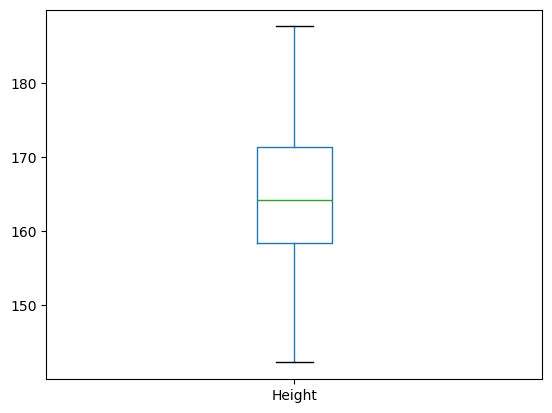

In [24]:
body_df.boxplot(
    column=['Height'],
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.show()

반면에 체중 데이터에는 IQR 기준 이상치가 존재한다.

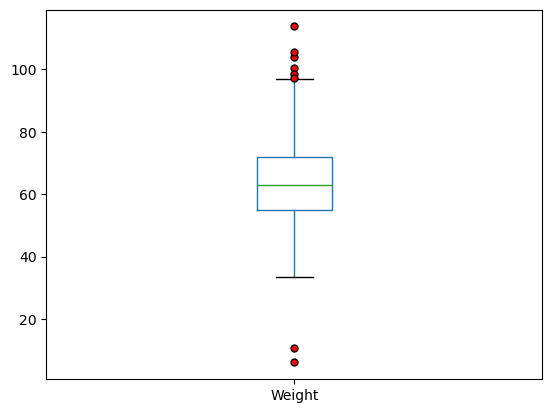

In [25]:
body_df.boxplot(
    column=['Weight'],
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.show()

### 히스토그램

상자 그림은 사분위수와 이상치를 파악하는 데는 용이하지만, 데이터의 전체적인 윤곽과 세부 분포를 직관적으로 파악하기에는 한계가 있다. 이럴 때 **히스토그램**<font size='2'>histogram</font>을 활용하면 데이터를 특정 범위의 구간(bins) 단위로 나눈 뒤, 각 구간에 속하는 데이터의 빈도(개수)를 막대로 표시하여 데이터 분포의 전반적인 형태를 한눈에 살펴볼 수 있다.

데이터프레임의 `hist()` 메서드(또는 Matplotlib의 `hist()`)를 활용하면 손쉽게 히스토그램을 그릴 수 있다. 히스토그램의 구간(bins) 개수나 너비를 조정하는 구체적인 설정 방법은 나중에 자세히 다룬다.

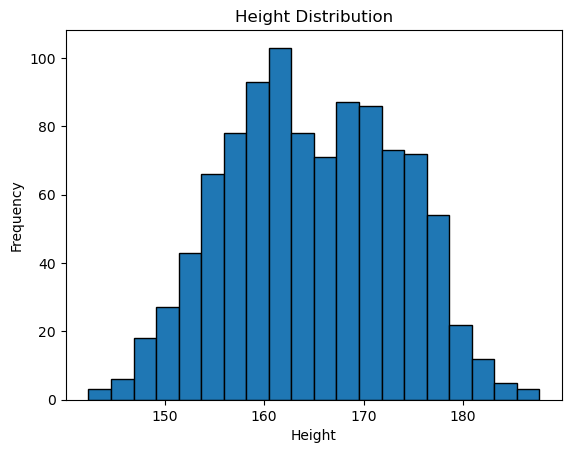

In [26]:
body_df['Height'].hist(bins=20, edgecolor='black', grid=False)

plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Height Distribution')
plt.show()

히스토그램의 막대 개수를 고정(위 코드에서는 `bins=20`)하는 방식 외에도, 아래와 같이 데이터의 범위를 기준으로 직접 막대의 구간(bins) 간격을 설정하여 나타낼 수도 있다. 여기서는 `np.arange()`를 활용해 관측된 키의 최솟값에서 5 작고, 최댓값에서 5 큰 범위 내에서 5의 간격을 가지는 구간들의 경곗값을 생성한다.

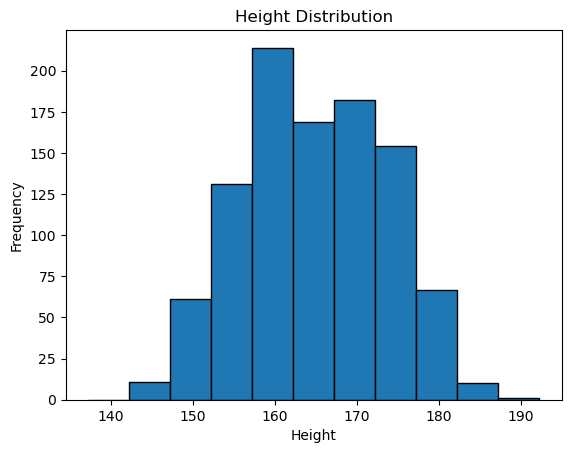

In [27]:
bins = np.arange(body_df['Height'].min() - 5, body_df['Height'].max() + 5, 5)
body_df['Height'].hist(bins=bins, edgecolor='black', grid=False)

plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Height Distribution')
plt.show()

시각화를 위한 `seaborn` 라이브러리를 활용하면 분포를 보다 세련된 형태로 손쉽게 파악할 수 있다. `sns.histplot()` 함수를 호출하여 동일한 히스토그램을 그릴 수 있다.

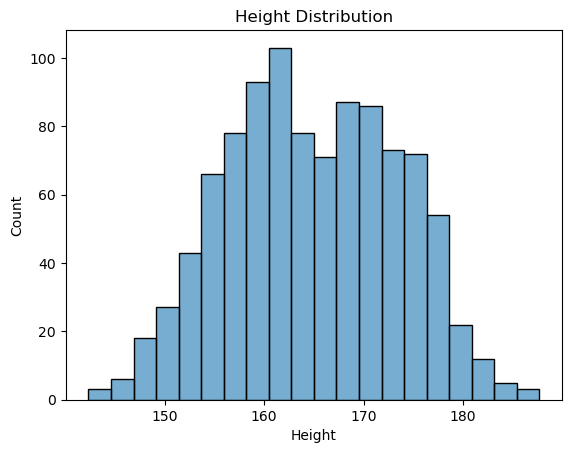

In [28]:
import seaborn as sns

sns.histplot(data=body_df, x='Height', bins=20, alpha=0.6)

plt.title('Height Distribution')
plt.show()

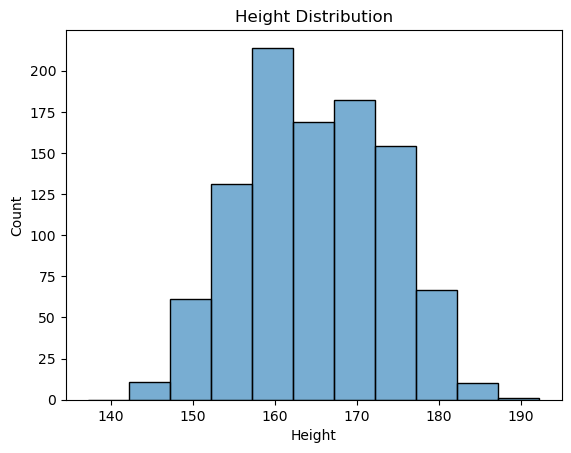

In [29]:
import seaborn as sns

bins = np.arange(body_df['Height'].min() - 5, body_df['Height'].max() + 5, 5)
sns.histplot(data=body_df, x='Height', bins=bins, alpha=0.6)

plt.title('Height Distribution')
plt.show()

### 기술통계 종합

데이터프레임의 `describe()` 메서드는
데이터의 개수, 평균값, 표준편차, 최댓값, 최소값, 사분위수에 대한 정보를 담고 있는 데이터프레임을 생성한다. 지금까지 개별적으로 살펴본 통계량을 한번에 확인할 수 있어 매우 유용하다.
단, 표준편차가 불편분산에 근거한 값임에 주의한다.

In [30]:
body_df['Height'].describe()

count    1000.00000
mean      164.81170
std         8.54853
min       142.30000
25%       158.40000
50%       164.30000
75%       171.42500
max       187.70000
Name: Height, dtype: float64

지금까지 키 데이터로 각 기술통계량의 의미와 계산 방법을 익혔다.
이제 `body_df` 데이터프레임 전체에 `describe()` 메서드를 적용하면 1000명의 모든 수치형 특성(나이, 키, 몸무게, 체지방률)에 대한 기술통계를 한번에 확인할 수 있다.

In [31]:
body_df.describe()

,Age,Height,Weight,BFP
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,48.177000,164.81170,64.138600,28.457900
std,15.245002,8.54853,11.983963,7.027338
min,20.000000,142.30000,6.000000,8.200000
25%,35.000000,158.40000,55.075000,23.475000
50%,49.000000,164.30000,62.800000,28.850000
75%,61.000000,171.42500,71.925000,33.500000
max,80.000000,187.70000,113.800000,50.500000


## 그룹별 기술통계

범주형 변수를 기준으로 데이터를 나누어 그룹별 기술통계를 확인하면 집단 간의 특성과 차이를 더 깊이 이해할 수 있다. 
`body_df` 데이터프레임의 경우, 성별(`Sex`) 변수를 기준으로 `groupby()` 메서드를 활용하면 남성과 여성 그룹의 특성을 각각 비교할 수 있다.

먼저 각 성별 데이터의 수(데이터 개수)와 비율을 확인해본다.

In [32]:
body_df.groupby('Sex').size()

Sex
F    500
M    500
dtype: int64

In [33]:
body_df.groupby('Sex').size() / len(body_df)

Sex
F    0.5
M    0.5
dtype: float64

이어서 각 변수에 대해 성별 평균을 산출한다.

In [34]:
body_df.groupby('Sex').mean()

,Age,Height,Weight,BFP
Sex,,,,
F,49.030,158.2028,56.0244,31.9302
M,47.324,171.4206,72.2528,24.9856


다양한 기술 통계(평균, 표준편차, 최소, 최대값)를 한 번에 보고 싶다면 `agg()` 메서드를 사용한다.

In [35]:
body_df.groupby('Sex').agg(['mean', 'std', 'min', 'max'])

Age                           Height                           Weight  \
       mean        std   min   max      mean       std    min    max     mean   
Sex                                                                             
F    49.030  14.895935  20.0  79.0  158.2028  5.302243  142.3  172.6  56.0244   
M    47.324  15.554385  20.0  80.0  171.4206  5.536897  154.7  187.7  72.2528   

                                 BFP                        
           std   min    max     mean       std   min   max  
Sex                                                         
F     7.409040   6.0   90.9  31.9302  5.995401  13.9  50.5  
M    10.033957  10.8  113.8  24.9856  6.225675   8.2  44.8

:::{note} 다중 인덱스

위 결과를 보면 열 인덱스가 두 계층으로 구성된 **다중 인덱스**<font size='2'>MultiIndex</font> 객체다.

- 1계층: `Age`, `Height`, `Weight` 등 원래 열 이름
- 2계층: `mean`, `std`, `min`, `max` 등 집계 함수 이름
:::

다중 인덱스를 사용하는 행 또는 열에 대한 인덱싱은 인덱스로 구성된 튜플을 사용하면 된다.
예를 들어, 아래 코드는 나이의 성별 평균값을 확인한다.

In [36]:
df_double_index = body_df.groupby('Sex').agg(['mean', 'std', 'min', 'max'])
df_double_index.loc[:, ('Age', 'mean')]

Sex
F    49.030
M    47.324
Name: (Age, mean), dtype: float64

컬럼별로 서로 다른 집계 함수를 적용하는 것 또한 `agg()` 메서드로 가능하다.

In [37]:
body_df.groupby('Sex').agg({'Height': 'mean', 'Weight': 'median', 'BFP': 'std'})

,Height,Weight,BFP
Sex,,,
F,158.2028,55.3,5.995401
M,171.4206,71.4,6.225675


기술통계 조건에 따라 그룹을 걸러내고 싶다면 `groupby()` 객체에 `filter()` 메서드를 사용한다. 예를 들어 전체 평균 키가 대상이 아니라 "평균 키가 170cm 이상인 그룹(여기서는 남성)"만 남기도록 필터링할 수 있다.

In [38]:
# 평균 키가 170 이상인 그룹만 유지
body_df.groupby('Sex').filter(lambda g: g['Height'].mean() >= 170)

,Sex,Age,Height,Weight,BFP
ID,,,,,
M001,M,38.0,177.2,73.4,20.9
M002,M,51.0,175.4,79.3,24.3
M003,M,26.0,175.6,76.1,24.2
M004,M,21.0,176.9,77.6,26.6
M005,M,25.0,177.1,69.1,23.1
...,...,...,...,...,...
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6


기술통계 수치로만 비교가 어렵다면 상자 그림(boxplot) 등 시각적 자료를 함께 사용하는 것이 효과적이다.
`boxplot()` 메서드에 `by` 인자를 지정하면 성별과 같은 범주형 변수를 기준으로 수치들의 분포 범위를 보다 직관적으로 비교할 수 있다.

키 데이터에서 성별 구분을 하면 IQR 기준 이상치가 포함되어 있음이 확인된다.
이렇듯 동일한 데이터에 대해서 처리방식에 따라 결과가 달라질 수 있음에 주의한다.

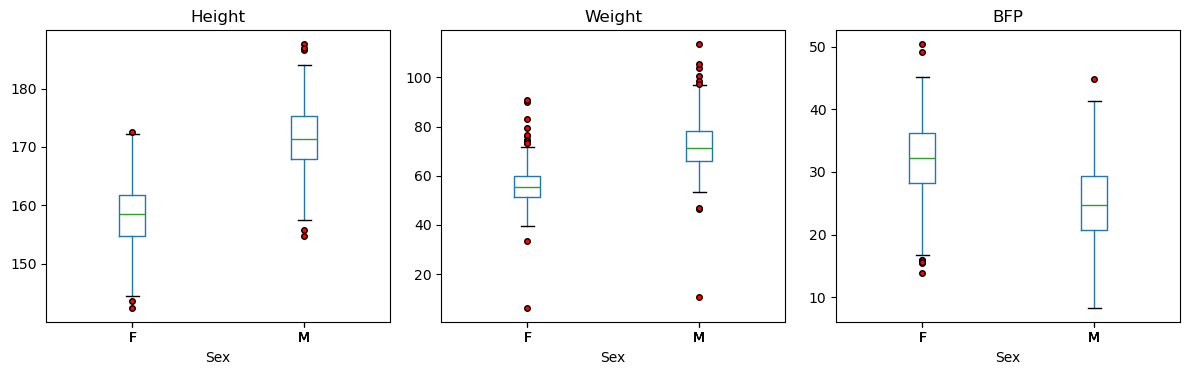

In [39]:
body_df.boxplot(
    column=['Height', 'Weight', 'BFP'],
    by='Sex',
    layout=(1, 3),
    figsize=(12, 4),
    grid=False,
    sharey=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4)
)
plt.suptitle('')
plt.tight_layout()
plt.show()

마찬가지로 성별에 따른 키의 분포를 히스토그램으로 시각화하여 겹쳐볼 수 있다.
이를 위해 `seaborn` 라이브러리의 `histplot()`을 활용하면 더욱 직관적이고 깔끔한 그룹별 히스토그램을 작성할 수 있다. `hue` 인자에 기준이 될 범주형 변수를 전달해주면 그룹별 분포가 겹쳐서 출력된다.

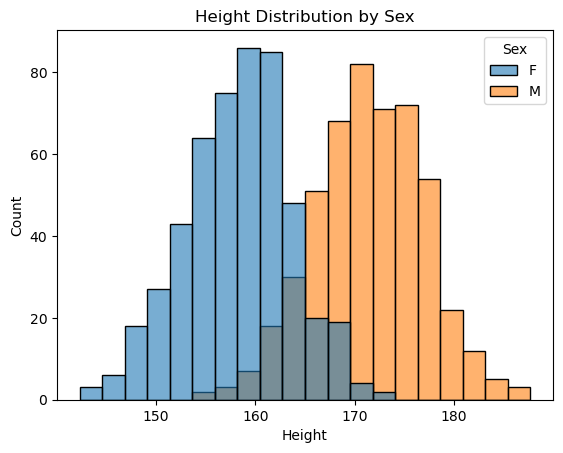

In [40]:
import seaborn as sns

sns.histplot(data=body_df, x='Height', hue='Sex', bins=20, alpha=0.6)

plt.title('Height Distribution by Sex')
plt.show()

## 기술통계량 활용

### 이상치 탐지

**이상치**<font size='2'>outlier</font>는 다른 데이터와 현저히 다른 값으로, 분석 결과를 왜곡할 수 있다. IQR을 이용한 이상치 탐지는 가장 널리 쓰이는 방법이다.

- 이상치 기준: Q1 - 1.5 × IQR 미만이거나 Q3 + 1.5 × IQR 초과인 값
- 이 범위를 **울타리**<font size='2'>fence</font>라 부르며, 상자 그림의 수염(whisker) 끝이 이 위치에 해당한다.

:::{warning} 이상치 정의

IQR 방법을 통해 특정 범위를 벗어난 데이터를 이상치(outlier)로 간주하는 것은 여러 탐지 기법 중 하나일 뿐이다.
데이터의 특성, 수집 방법, 그리고 분석 목적에 따라 이상치를 정의하고 판단하는 기준은 다양하게 달라질 수 있다.

예를 들어, 데이터의 상·하위 1%, 5% 등 특정 비율표를 벗어나는 값을 이상치로 다루기도 하며, 정규 분포를 따른다고 가정할 때 표준편차 구간을 벗어난 값을 이상치로 취급하기도 한다.
:::

`body_df`의 몸무게(`Weight`) 데이터에 포함된 이상치를 확인한다. 먼저 사분위수와 울타리 값을 계산한다.

In [41]:
Q1 = body_df['Weight'].quantile(0.25)
Q3 = body_df['Weight'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'Q1: {Q1},  Q3: {Q3},  IQR: {IQR}')
print(f'하한 울타리: {lower:.2f}')
print(f'상한 울타리: {upper:.2f}')

Q1: 55.075,  Q3: 71.92500000000001,  IQR: 16.85000000000001
하한 울타리: 29.80
상한 울타리: 97.20


울타리 범위를 벗어난 행을 불리언 인덱싱으로 추출한다.

In [42]:
weights_df = body_df['Weight']
mask = (weights_df < lower) | (weights_df > upper)
weights_df[mask]

ID
F470      6.0
M042     10.8
M208    100.5
M210    103.9
M218    113.8
M331     98.5
M342     97.4
M360    105.6
Name: Weight, dtype: float64

이상치를 포함한 데이터 샘플을 제거한 데이터프레임을 만들고, 제거 전후의 평균값을 비교한다.
평균값은 조금 달라진 반면에 중앙값은 그대로다.

In [43]:
weights_df.mean()

np.float64(64.13860000000001)

In [44]:
weights_clean = weights_df[~mask]

print(f'이상치 제거 전 평균:  {weights_df.mean():.4f}')
print(f'이상치 제거 후 평균:  {weights_clean.mean():.4f}')
print()
print(f'이상치 제거 전 중앙값: {weights_df.median():.4f}')
print(f'이상치 제거 후 중앙값: {weights_clean.median():.4f}')

이상치 제거 전 평균:  64.1386
이상치 제거 후 평균:  64.0142

이상치 제거 전 중앙값: 62.8000
이상치 제거 후 중앙값: 62.8000


성별 그룹별로 이상치 제거 전후의 평균값과 중앙값을 비교하면,
평균값에 비해 중앙값의 변화가 상대적으로 매우 작음에 주의한다.

In [45]:
sex_weight_df = body_df[['Sex', 'Weight']]

print('=== 이상치 제거 전 ===')
print(sex_weight_df.groupby('Sex')['Weight'].agg(['mean', 'median']))
print()
print('=== 이상치 제거 후 ===')
print(sex_weight_df[~mask].groupby('Sex')['Weight'].agg(['mean', 'median']))

=== 이상치 제거 전 ===
        mean  median
Sex                 
F    56.0244    55.3
M    72.2528    71.4

=== 이상치 제거 후 ===
          mean  median
Sex                   
F    56.124649    55.3
M    71.999797    71.2


### 데이터 정규화

In [46]:
body_df.describe()

,Age,Height,Weight,BFP
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,48.177000,164.81170,64.138600,28.457900
std,15.245002,8.54853,11.983963,7.027338
min,20.000000,142.30000,6.000000,8.200000
25%,35.000000,158.40000,55.075000,23.475000
50%,49.000000,164.30000,62.800000,28.850000
75%,61.000000,171.42500,71.925000,33.500000
max,80.000000,187.70000,113.800000,50.500000


기술통계량(평균, 표준편차, 최댓값, 최솟값)은 데이터를 요약하는 것 외에도 데이터를 변환하는 데 직접 활용된다.
데이터의 특성마다 단위와 범위가 다르면 직접 비교하거나 분석 모델에 함께 사용하기 어렵다.
예를 들어, 키는 128~205 범위의 값이고 체지방률은 8~50 범위의 값이기에 두 특성의 값을 일대일로 비교하기는 어렵다.
이런 경우 데이터를 **정규화**<font size='2'>normalization</font>하여 특성값들의 범위를 통일시키는 기법을 적용한다.
대표적인 정규화 기법으로 **min-max 스케일링**과 **표준화**(z-score)가 있다.

**min-max 스케일링**

min-max 스케일링은 데이터의 최솟값을 0, 최댓값을 1로 맞추어 모든 값을 0과 1 사이로 변환하는 기법이다.
현재 데이터 값이 전체 데이터 구간(최댓값 - 최솟값)에서 차지하는 상대적인 위치를 비율로 계산하며, 수식은 다음과 같다.

$$
x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

여기서 $x$는 원래 데이터 값, $x_{\min}$와 $x_{\max}$는 각각 $x$가 속한 데이터셋의 최솟값과 최댓값을 가리킨다.

`body_df`의 키 데이터에 min-max 스케일링을 적용한다.

In [47]:
height_col = body_df[['Height']]
height_minmax = (height_col - height_col.min()) / (height_col.max() - height_col.min())
body_df['Height_minmax'] = height_minmax
body_df['Height_minmax']

ID
F001    0.420705
F002    0.568282
F003    0.464758
F004    0.480176
F005    0.233480
          ...   
M496    0.751101
M497    0.332599
M498    0.550661
M499    0.607930
M500    0.691630
Name: Height_minmax, Length: 1000, dtype: float64

변환된 데이터의 최솟값은 0, 최댓값은 1이 된다.

In [48]:
body_df.describe()

,Age,Height,Weight,BFP,Height_minmax
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,48.177000,164.81170,64.138600,28.457900,0.495852
std,15.245002,8.54853,11.983963,7.027338,0.188294
min,20.000000,142.30000,6.000000,8.200000,0.000000
25%,35.000000,158.40000,55.075000,23.475000,0.354626
50%,49.000000,164.30000,62.800000,28.850000,0.484581
75%,61.000000,171.42500,71.925000,33.500000,0.641520
max,80.000000,187.70000,113.800000,50.500000,1.000000


**표준화**

표준화는 데이터의 평균을 0, 표준편차를 1로 맞추어 변환하는 기법이다.
변환된 데이터 값을 **z-점수**<font size='2'>z-score</font>라고 부르며, 각 데이터 값이 평균으로부터 표준편차의 몇 배만큼 떨어져 있는지를 나타낸다. 수식은 다음과 같다.

$$
z = \frac{x - \bar{x}}{S}
$$

여기서 $x$는 원래 데이터 값, $\bar{x}$와 $S$는 $x$가 속한 데이터셋의 평균값과 표준편차를 가리킨다.

`body_df`의 키 데이터에 표준화 스케일링을 적용한다.

In [49]:
height_z = (height_col - height_col.mean()) / height_col.std(ddof=0)
body_df['Height_z'] = height_z
body_df['Height_z']

ID
F001   -0.399298
F002    0.384855
F003   -0.165222
F004   -0.083296
F005   -1.394118
          ...   
M496    1.356268
M497   -0.867448
M498    0.291225
M499    0.595523
M500    1.040266
Name: Height_z, Length: 1000, dtype: float64

변환된 데이터의 평균값과 표준편차가 각각 0과 1(에 매우 가까운 값)이 된다.

In [50]:
body_df.describe()

,Age,Height,Weight,BFP,Height_minmax,Height_z
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,48.177000,164.81170,64.138600,28.457900,0.495852,-3.410605e-16
std,15.245002,8.54853,11.983963,7.027338,0.188294,1.000500e+00
min,20.000000,142.30000,6.000000,8.200000,0.000000,-2.634718e+00
25%,35.000000,158.40000,55.075000,23.475000,0.354626,-7.504107e-01
50%,49.000000,164.30000,62.800000,28.850000,0.484581,-5.988819e-02
75%,61.000000,171.42500,71.925000,33.500000,0.641520,7.740055e-01
max,80.000000,187.70000,113.800000,50.500000,1.000000,2.678794e+00


## 연습문제

**문제 1: 기술통계**

`iris.csv` 파일은 통계학자 피셔(R. A. Fisher)가 1936년에 발표한 **붓꽃(Iris) 데이터셋**으로, 세 품종의 붓꽃(Setosa, Versicolor, Virginica) 각 50개씩 총 150개 샘플에 대한 네 가지 수치 측정값과 품종 문자열을로 구성된 범주형 특성을 담고 있다.

| 특성 | 설명 | 타입 |
|------|------|------|
| `sepal.length` | 꽃받침 길이 (cm) | 수치형 |
| `sepal.width` | 꽃받침 너비 (cm) | 수치형 |
| `petal.length` | 꽃잎 길이 (cm) | 수치형 |
| `petal.width` | 꽃잎 너비 (cm) | 수치형 |
| `variety` | 품종 (Setosa, Versicolor, Virginica) | 범주형 |

In [51]:
iris_df = pd.read_csv(data_url + 'iris.csv')
iris_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


데이터프레임의 기본 정보를 확인한다.

In [52]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


(1) `petal.length`의 평균을 계산하라.

답:

판다스 시리즈의 `.mean()` 메서드를 사용하여 `petal.length` 열의 평균을 구한다.

In [53]:
iris_df['petal.length'].mean()

np.float64(3.7580000000000005)

(2) `sepal.width`의 중앙값을 계산하라.

답:

`.median()` 메서드는 데이터를 크기순으로 정렬했을 때 가운데 위치하는 값을 반환한다.

In [54]:
iris_df['sepal.width'].median()

np.float64(3.0)

(3) `petal.width`에서 가장 빈번하게 등장하는 값(최빈값)을 하나 구하라.

답:

판다스 시리즈의 `.mode()` 메서드는 최빈값을 시리즈로 반환한다. 최빈값이 여러 개일 수 있으므로 인덱스 `[0]`으로 첫 번째 값을 꺼낸다.

In [55]:
iris_df['petal.width'].mode()[0]

np.float64(0.2)

(4) `sepal.length`의 제1, 제3 사분위수와 사분범위(IQR)를 계산하라.

답:

`.quantile()` 메서드에 0.25와 0.75를 지정하여 제1, 제3 사분위수를 구한다. IQR은 Q3 - Q1이다.

In [56]:
Q1 = iris_df['sepal.length'].quantile(0.25)
Q3 = iris_df['sepal.length'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

Q1: 5.1, Q3: 6.4, IQR: 1.3000000000000007


(5) `sepal.width`에 대한 상자 그림을 그려라.

답:

`.boxplot()` 메서드를 활용한다. 

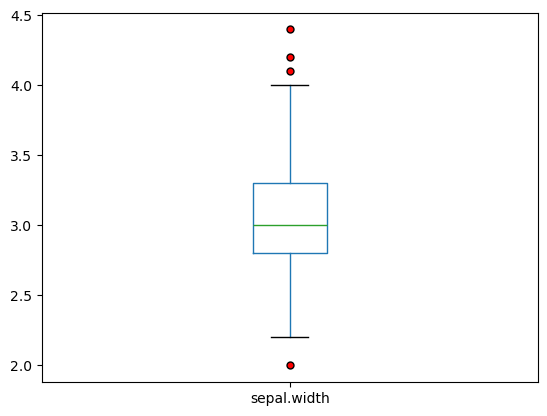

In [57]:
iris_df.boxplot(
    column=['sepal.width'],
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.show()

(6) `petal.width`의 범위, 분산(편향), 표준편차(편향)를 계산하라.

답:

범위는 `.max() - .min()`으로 구한다. 판다스의 `.var()`와 `.std()`는 기본적으로 비편향(ddof=1)을 사용하므로, 편향 분산/표준편차를 구하려면 `ddof=0`을 지정한다.

In [58]:
pw = iris_df['petal.width']
print(f"범위: {pw.max() - pw.min()}")
print(f"분산: {pw.var(ddof=0)}")
print(f"표준편차: {pw.std(ddof=0)}")

범위: 2.4
분산: 0.5771328888888888
표준편차: 0.7596926279021594


(7) `petal.length`를 min-max 스케일링하여 `petal_length_scaled` 열로 데이터프레임에 추가하라.

답:

`(x - min) / (max - min)` 공식을 판다스 시리즈 연산으로 적용한 뒤, 결과를 새 열로 추가한다.

In [59]:
pl = iris_df['petal.length']
iris_df['petal_length_scaled'] = (pl - pl.min()) / (pl.max() - pl.min())
iris_df[['petal.length', 'petal_length_scaled']].head()

,petal.length,petal_length_scaled
0,1.4,0.067797
1,1.4,0.067797
2,1.3,0.050847
3,1.5,0.084746
4,1.4,0.067797


(8) `sepal.width`를 표준화(Z-score)하여 `sepal_width_z` 열로 데이터프레임에 추가하라.

답:

`(x - mean) / std` 공식으로 Z-score를 계산한다. 편향 표준편차(`ddof=0`)를 사용한다.

In [60]:
sw = iris_df['sepal.width']
iris_df['sepal_width_z'] = (sw - sw.mean()) / sw.std(ddof=0)
iris_df[['sepal.width', 'sepal_width_z']].head()

,sepal.width,sepal_width_z
0,3.5,1.019004
1,3.0,-0.131979
2,3.2,0.328414
3,3.1,0.098217
4,3.6,1.249201


(9) `sepal.width`에서 IQR 기반 이상치를 탐지하라. 이상치의 개수와 해당 행을 출력하라.

답:

IQR 기반 이상치 판별 기준: Q1 - 1.5×IQR 미만이거나 Q3 + 1.5×IQR 초과인 값을 이상치로 간주한다. 불리언 인덱싱으로 해당 행을 추출한다.

In [61]:
sw = iris_df['sepal.width']
Q1 = sw.quantile(0.25)
Q3 = sw.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = iris_df[(sw < lower) | (sw > upper)]
print(f"이상치 개수: {len(outliers)}")
outliers

이상치 개수: 4


,sepal.length,sepal.width,petal.length,petal.width,variety,petal_length_scaled,sepal_width_z
15,5.7,4.4,1.5,0.4,Setosa,0.084746,3.090775
32,5.2,4.1,1.5,0.1,Setosa,0.084746,2.400185
33,5.5,4.2,1.4,0.2,Setosa,0.067797,2.630382
60,5.0,2.0,3.5,1.0,Versicolor,0.423729,-2.433947


(10) `petal.length`의 히스토그램을 그려라. 적절한 구간(bins)을 설정할 것.

답:

`plt.hist()`로 히스토그램을 그린다. `np.arange()`를 사용하여 데이터 범위에 맞는 구간을 설정한다.

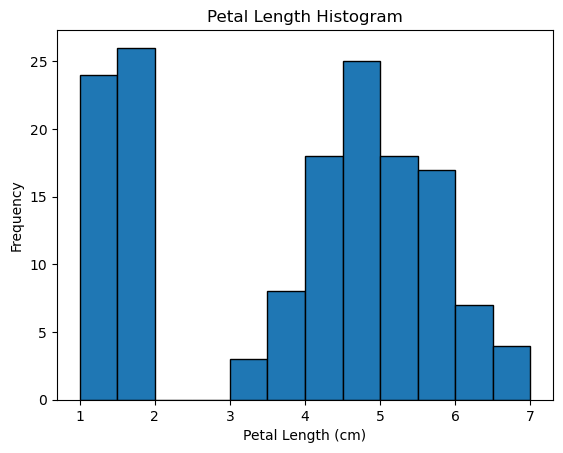

In [62]:
pl = iris_df['petal.length']
bins = np.arange(pl.min(), pl.max() + 0.5, 0.5)

plt.hist(pl, bins=bins, edgecolor='black')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.title('Petal Length Histogram')
plt.show()

**문제 2: 그룹별 기술통계**

`groupby()` 메서드를 활용하여 붓꽃 데이터셋(`iris_df`)의 품종(`variety`)별 기술통계를 구한다.

(1) `variety` 컬럼을 기준으로 품종별 샘플 수를 구하라.

답:

`groupby('variety').size()`는 `variety` 컬럼을 기준으로 그룹을 만들고 각 그룹의 행 수를 반환한다.

In [63]:
iris_df.groupby('variety').size()

variety
Setosa        50
Versicolor    50
Virginica     50
dtype: int64

(2) 품종별 모든 수치형 변수의 평균을 구하라.

답:

`groupby('variety').mean(numeric_only=True)`는 품종별로 수치형 변수 전체의 평균을 계산하여 데이터프레임으로 반환한다.

In [64]:
iris_df.groupby('variety').mean(numeric_only=True)

,sepal.length,sepal.width,petal.length,petal.width,petal_length_scaled,sepal_width_z
variety,,,,,,
Setosa,5.006,3.428,1.462,0.246,0.078305,0.853263
Versicolor,5.936,2.770,4.260,1.326,0.552542,-0.661432
Virginica,6.588,2.974,5.552,2.026,0.771525,-0.191831


(3) 품종별 `petal.length`의 평균, 표준편차, 최솟값, 최댓값을 구하라.

답:

`groupby('variety')['petal.length'].agg([...])`는 `petal.length` 열을 품종별로 그룹화한 뒤 지정한 여러 통계량을 한 번에 계산한다.

In [65]:
iris_df.groupby('variety')['petal.length'].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
variety,,,,
Setosa,1.462,0.173664,1.0,1.9
Versicolor,4.260,0.469911,3.0,5.1
Virginica,5.552,0.551895,4.5,6.9


(4) `describe()` 메서드를 사용하여 품종별 `sepal.length`의 기술통계를 구하라.

답:

`groupby('variety')['sepal.length'].describe()`는 `sepal.length` 열을 품종별로 그룹화한 뒤 개수·평균·표준편차·최솟값·사분위수·최댓값 등 기본 기술통계를 한 번에 출력한다.

In [66]:
iris_df.groupby('variety')['sepal.length'].describe()

,count,mean,std,min,25%,50%,75%,max
variety,,,,,,,,
Setosa,50.0,5.006,0.352490,4.3,4.800,5.0,5.2,5.8
Versicolor,50.0,5.936,0.516171,4.9,5.600,5.9,6.3,7.0
Virginica,50.0,6.588,0.635880,4.9,6.225,6.5,6.9,7.9


**문제 3: 넘파이 어레이 활용 기술통계 분석**

기술통계는 넘파이 어레이만으로도 충분히 할 수 있음을 이번 문제에서 보여준다.

문제 설정을 위해 기본 데이터 저장소에 있는 `sc_weir.csv` 파일을 활용한다.
이 데이터는 광주광역시에서부터 전라남도 나주를 거쳐 서해까지 이어지는 영산강에 설치된 승촌보에서 측정한 두 종류의 데이터를 담고 있다.

- `Chl-a`: 녹조 발생의 주요 요인인 클로로필-A 수치 100개
- `Discharge`: 보에서 방출되는 시간당 방류량 수치 100개

이 데이터를 수집한 목적은 클로로필-A의 농도와 보 방류량과의 상관관계를 확인하기 위함이다.
일반적으로 방류량이 많을수록 클로로필-A 농도는 떨어지며, 반대로 클로로필-A 농도가 높을수록 수질(water quality)이 나빠진다.

In [67]:
sc_weir_df = pd.read_csv(data_url+'sc_weir.csv')
sc_weir_df

,Chl-a,Discharge
0,51,25
1,51,25
2,53,24
3,53,24
4,54,22
...,...,...
95,122,9
96,122,9
97,124,49
98,125,9


데이터프레임의 `values` 속성은 행과 열의 정보를 제외한 항목들로만 구성된
동일한 모양의 넘파이 어레이를 가리킨다.

In [68]:
sc_weir_arr = sc_weir_df.values

변환된 넘파이 어레이의 형태(행 수, 열 수)를 확인한다.

In [69]:
sc_weir_arr.shape

(100, 2)

처음 10개의 항목은 다음과 같다.

In [70]:
sc_weir_arr[:10]

array([[51, 25],
       [51, 25],
       [53, 24],
       [53, 24],
       [54, 22],
       [55, 22],
       [57, 21],
       [57, 21],
       [59, 20],
       [60, 20]])

(1) 방류량의 평균값을 계산하라.

답:

방류량은 1번 열의 데이터다.

In [71]:
discharge_arr = sc_weir_arr[:, 1]

`np.mean()` 함수를 사용하여 방류량 어레이의 평균을 구한다.

In [72]:
np.mean(discharge_arr)

np.float64(14.93)

(2) 방류량의 중앙값을 계산하라.

답:

`np.median()` 함수를 사용하여 방류량 어레이의 중앙값을 구한다.

In [73]:
np.median(discharge_arr)

np.float64(13.0)

(3) 방류량의 최빈값을 계산하라.

답:

넘파이에는 최빈값을 단독으로 구하는 함수가 없다. 대신 `np.unique()` 함수를 이용해 개별 값과 빈도수를 추출한 뒤 가장 큰 빈도를 가지는 값을 찾을 수 있다. 

`np.unique(..., return_counts=True)` 함수를 호출하면, 어레이 내에 존재하는 **고유한 값들의 어레이**와 
해당 값들이 등장하는 **빈도 어레이**를 튜플 형태로 반환한다.
이를 활용해 빈도가 가장 높은 고유값을 찾아 최빈값으로 사용한다.

In [74]:
vals, counts = np.unique(discharge_arr, return_counts=True)
mode_val = vals[counts.argmax()]
print(f"최빈값: {mode_val}")

최빈값: 11


(4) 방류량의 제1, 제3 사분위수를 계산하라.

답:

`np.percentile()` 함수에 분위수 인자로 백분율 (25와 75)을 지정하여 방류량의 제1, 제3 사분위수를 각각 계산한다.

In [75]:
Q1 = np.percentile(discharge_arr, 25)
Q3 = np.percentile(discharge_arr, 75)
print(Q1, Q3, sep='\n')

11.0
16.0


(5) 클로로필-A 데이터의 범위를 계산하라.

답:

클로로필-A 데이터는 0번 열의 데이터다.

In [76]:
chl_a_arr = sc_weir_arr[:, 0]

클로로필-A 데이터의 최솟값, 최댓값, 범위를 계산하여 출력한다.

In [77]:
print('min:', chl_a_arr.min())
print('max:', chl_a_arr.max())
print('범위:', chl_a_arr.max() - chl_a_arr.min())

min: 51
max: 125
범위: 74


(6) 클로로필-A 데이터의 분산을 계산하라.

답:

`np.var()` 함수에서 `ddof=0`을 지정한다.

In [78]:
np.var(chl_a_arr, ddof=0)

np.float64(506.8004000000001)

(7) 클로로필-A 데이터의 표준편차를 계산하라.

답:

`np.std()` 함수에 `ddof=0`을 옵션으로 지정한다.

In [79]:
np.std(chl_a_arr, ddof=0)

np.float64(22.51222778847087)

(8) 클로로필-A 데이터를 min-max 스케일링한 후 `sc_weir_arr`의 새로운 열로 추가하라.

답:

`(x - min) / (max - min)` 공식으로 데이터를 정규화한 뒤, `np.column_stack()`을 사용하여 전체 데이터 배열에 새 열로 추가한다.

In [80]:
chl_a_min = chl_a_arr.min()
chl_a_max = chl_a_arr.max()
chl_a_scaled = (chl_a_arr - chl_a_min) / (chl_a_max - chl_a_min)

sc_weir_arr = np.column_stack([sc_weir_arr, chl_a_scaled])
sc_weir_arr[:5]

array([[5.10000000e+01, 2.50000000e+01, 0.00000000e+00],
       [5.10000000e+01, 2.50000000e+01, 0.00000000e+00],
       [5.30000000e+01, 2.40000000e+01, 2.70270270e-02],
       [5.30000000e+01, 2.40000000e+01, 2.70270270e-02],
       [5.40000000e+01, 2.20000000e+01, 4.05405405e-02]])

(9) 방류량 데이터를 표준화한 후 `sc_weir_arr`의 새로운 열로 추가하라.

답: `(x - mean) / std` 공식을 사용하여 방류량 데이터를 변환한 후, `np.column_stack()`을 사용하여 데이터 세트에
횡으로 결헙한다.

In [81]:
discharge_mean = discharge_arr.mean()
discharge_std = discharge_arr.std(ddof=0)
discharge_z = (discharge_arr - discharge_mean) / discharge_std

sc_weir_arr = np.column_stack([sc_weir_arr, discharge_z])
sc_weir_arr[:5]

array([[5.10000000e+01, 2.50000000e+01, 0.00000000e+00, 1.58656273e+00],
       [5.10000000e+01, 2.50000000e+01, 0.00000000e+00, 1.58656273e+00],
       [5.30000000e+01, 2.40000000e+01, 2.70270270e-02, 1.42900933e+00],
       [5.30000000e+01, 2.40000000e+01, 2.70270270e-02, 1.42900933e+00],
       [5.40000000e+01, 2.20000000e+01, 4.05405405e-02, 1.11390253e+00]])